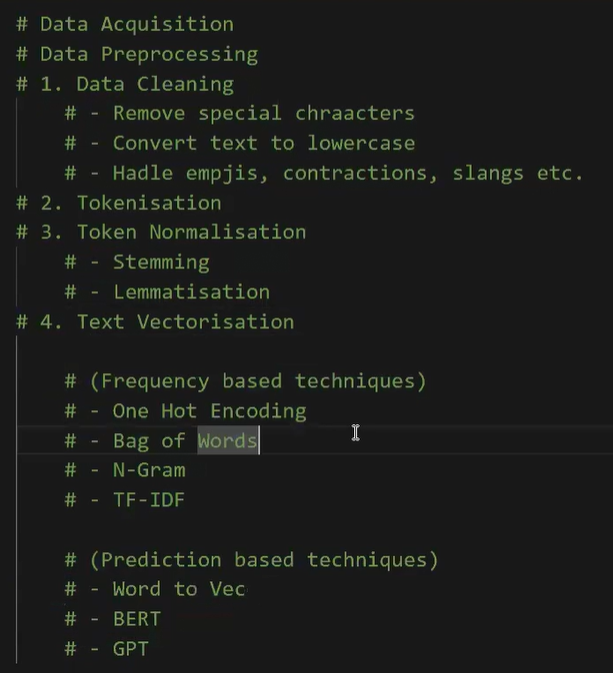

# Text Vectorisation

## Basic

In [1]:
text = "Text preprocessing is an extremely important step for many NLP tasks (like classifying/categorizing texts). It's ensuring your data is clean and ready, isn't it? Running and jumping are fun activities."

In [ ]:
# %pip install pandas

  Using cached pandas-2.3.3-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
Using cached pandas-2.3.3-cp313-cp313-win_amd64.whl (11.0 MB)
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)

   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
   ------------- -------------------------- 1/3 [tzdata]
   ------------- -------------------------- 1/3 [tzdata]
   ------------- -------------------------- 1/3 [tzdata]
   ------------- -------------------------- 1/3 [tzdata]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [pandas]
   ----------


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# %pip install scikit-learn

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.0 MB 1.7 MB/s eta 0:00:05
   ------ --------------------------------- 1.3/8.0 MB 2.1 MB/s eta 0:00:04
   ---------- ----------------------------- 2.1/8.0 MB 2.6 MB/s eta 0:00:03
   -------------- ------------------------- 2.9/8.0 MB 2.9 MB/s eta 0:00:02
   -------------------- ------------------- 4.2/8.0 MB 3.4 MB/s eta 0:00:02
   -------------------------- ------------- 5.2/8.0 MB 3.7 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.0 MB 4.0 MB/s eta 0:00:01
   ---------------------------------------  7.9/8.0 MB 4.3 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 4.2 MB/s  0:00:01
   ---------------------------------------- 0.0/38.5 MB ? eta -:--:--
   - -------------------------------------


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

import numpy as np
import pandas as pd

In [11]:
stemmer = PorterStemmer()

In [14]:
lemmatiser = WordNetLemmatizer()

In [20]:
def clean_tag(tag):
    if (tag.startswith('V')):
        return 'v'
    elif (tag.startswith('J')):
        return 'a'
    elif (tag.startswith('R')):
        return 'r'
    else:
        return 'n'

In [26]:
# we don't remove duplicates from text otherwise the frequency will be 1. So, we remove them while considering the vocabulary not while cleaning the text.

def text_cleaner_and_tokeniser(text, strategy='stem'):
    text = text.lower() # converting to lowercase
    text = re.sub(r'[^a-z ]', '', text).strip() # removing special chars
    tokens = word_tokenize(text)
    if (strategy == 'stem'):
        normalised_tokens = [stemmer.stem(token) for token in tokens]   # Stemming
    else:
        normalised_tokens = []
        tokens_with_tag = nltk.pos_tag(tokens)
        for token,tag in tokens_with_tag:
            new_tag = clean_tag(tag)
            normalised_tokens.append(lemmatiser.lemmatize(token, new_tag))  # Lemmatisation
    return normalised_tokens

In [ ]:
print(text_cleaner_and_tokeniser(text)) # Stemming
print(text_cleaner_and_tokeniser(text, "lem")) # Lemmatisation

# We generally use lemmatisation rather than stemming

['text', 'preprocess', 'is', 'an', 'extrem', 'import', 'step', 'for', 'mani', 'nlp', 'task', 'like', 'classifyingcategor', 'text', 'it', 'ensur', 'your', 'data', 'is', 'clean', 'and', 'readi', 'isnt', 'it', 'run', 'and', 'jump', 'are', 'fun', 'activ']
['text', 'preprocessing', 'be', 'an', 'extremely', 'important', 'step', 'for', 'many', 'nlp', 'task', 'like', 'classifyingcategorizing', 'texts', 'it', 'ensure', 'your', 'data', 'be', 'clean', 'and', 'ready', 'isnt', 'it', 'run', 'and', 'jump', 'be', 'fun', 'activity']


In [27]:
cleaned_tokens = text_cleaner_and_tokeniser(text, "lem")
print(cleaned_tokens)

['text', 'preprocessing', 'be', 'an', 'extremely', 'important', 'step', 'for', 'many', 'nlp', 'task', 'like', 'classifyingcategorizing', 'texts', 'it', 'ensure', 'your', 'data', 'be', 'clean', 'and', 'ready', 'isnt', 'it', 'run', 'and', 'jump', 'be', 'fun', 'activity']


### One Hot Encoding

In [ ]:
pd.get_dummies(['h', 'e', 'l', 'l', 'o'])
# columns are unique

,e,h,l,o
0,False,True,False,False
1,True,False,False,False
2,False,False,True,False
3,False,False,True,False
4,False,False,False,True


In [40]:
one_hot_encoding = pd.get_dummies(cleaned_tokens, dtype='int')
one_hot_encoding

,activity,an,and,be,classifyingcategorizing,clean,data,ensure,extremely,for,...,many,nlp,preprocessing,ready,run,step,task,text,texts,your
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
2,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
7,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


In [54]:
one_hot_encoding.shape
# 30 words and 26 unique values. the number of words are rows and unique tokens are columns. columns always represent the size of a vector.
# each vector is represented in 26 scalar values. so, vector size is 26 here.
# as the text increases, vector size also increases.

(30, 26)

In [53]:
len(cleaned_tokens), len(list(set(cleaned_tokens)))

(30, 26)

### Bag of Words

In [61]:
from sklearn.feature_extraction.text import CountVectorizer

In [62]:
vec = CountVectorizer()

In [70]:
corpus = ['This is a cat.', 'This is a dog.', 'This is not a cat.', 'cat is cat']

In [71]:
vec.fit(corpus) # learns the vocabulary
sparse_matrix = vec.fit_transform(corpus) # learns the voc and creates a Sparse Matrix.
sparse_matrix

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 12 stored elements and shape (4, 5)>

In [73]:
sparse_matrix.toarray()

array([[1, 0, 1, 0, 1],
       [0, 1, 1, 0, 1],
       [1, 0, 1, 1, 1],
       [2, 0, 1, 0, 0]])

In [75]:
vec.get_feature_names_out() # alphabetical order

array(['cat', 'dog', 'is', 'not', 'this'], dtype=object)

### N-Gram

In [84]:
vec_ngram = CountVectorizer(ngram_range=(1,2))

In [85]:
vec_ngram.fit_transform(corpus).toarray()

array([[1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1],
       [0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1],
       [1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1],
       [2, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0]])

In [86]:
vec_ngram.get_feature_names_out()

array(['cat', 'cat is', 'dog', 'is', 'is cat', 'is dog', 'is not', 'not',
       'not cat', 'this', 'this is'], dtype=object)

### Stop Words

In [96]:
from nltk.corpus import stopwords

In [ ]:
stp_words = stopwords.words('english')
print(stp_words)
print(len(stp_words))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

text -> more stop words -> more vector size -> more computational power


However, if you remove all the stop-words, we will loose the semantic meaning.


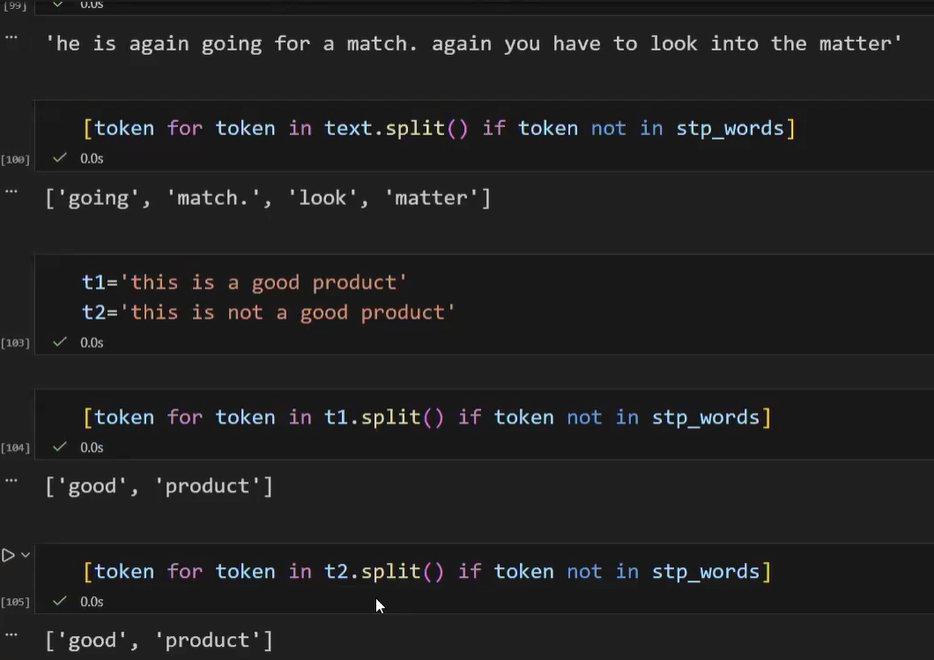


So, we can apply n-gram technique and remove the stop-words.


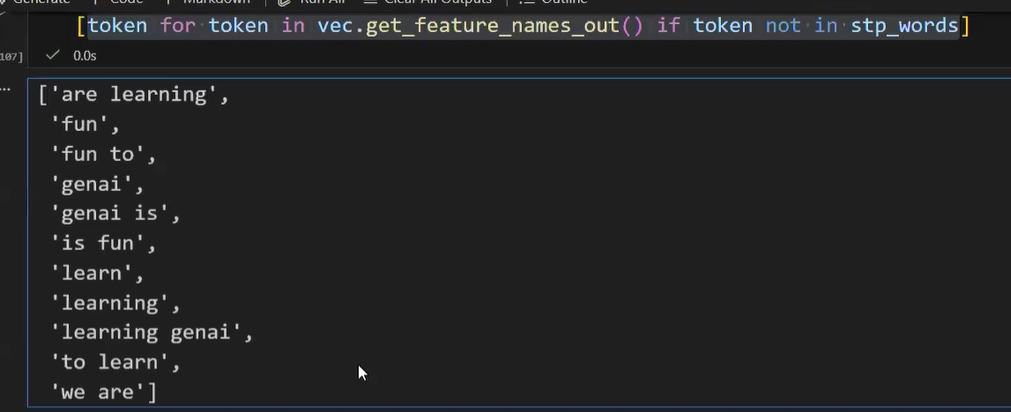

### TF-IDF

In [98]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [100]:
vec_f = TfidfVectorizer()

In [106]:
corpus

['This is a cat.', 'This is a dog.', 'This is not a cat.', 'cat is cat']

In [104]:
arr = vec_f.fit_transform(corpus).toarray()
arr

array([[0.61217198, 0.        , 0.5004907 , 0.        , 0.61217198],
       [0.        , 0.77157901, 0.40264194, 0.        , 0.49248889],
       [0.44181486, 0.        , 0.3612126 , 0.69218835, 0.44181486],
       [0.92564688, 0.        , 0.37838849, 0.        , 0.        ]])

In [107]:
arr.shape # rows -> corpus size, cols -> vocabulary

(4, 5)

In [103]:
vec_f.get_feature_names_out()

array(['cat', 'dog', 'is', 'not', 'this'], dtype=object)

In [109]:
corpus[0], arr[0]

('This is a cat.',
 array([0.61217198, 0.        , 0.5004907 , 0.        , 0.61217198]))

Vocab size is 80

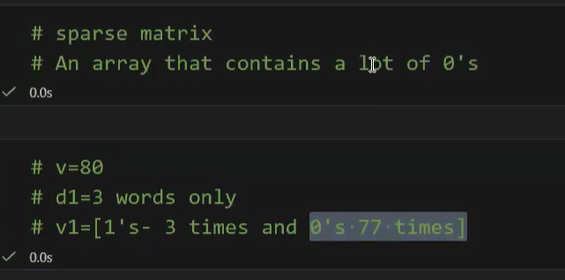

All the above are basic vectorizations and they loose the semantic meaning.

## Prediction Based

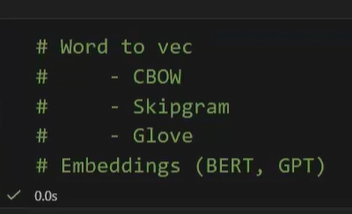